# Eksperimen & Pembuktian Teoretis: Optimasi Parameter Gaussian Process
**Berdasarkan Rasmussen & Williams (2006) - Chapter 5: Model Selection and Adaptation of Hyperparameters**  
*Dokumen Bimbingan Tugas Akhir #4*

---

## 📌 Ringkasan Konsep
Notebook ini mempraktikkan secara komputasional bagaimana hyperparameter Gaussian Process ($\mathbf{\theta} = [l, \sigma_f, \sigma_n]^T$) dioptimasi menggunakan:
1. **Marginal Likelihood (Evidence)**:
   $$\log p(\mathbf{y} \mid X, \mathbf{\theta}) = -\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y} - \frac{1}{2} \log |K_y| - \frac{N}{2} \log(2\pi)$$
2. **Occam's Razor Otomatis**: Keseimbangan antara kesesuaian data (*data-fit*) dan penalti kompleksitas (*complexity penalty*).
3. **Gradien Analitik via Dekomposisi Cholesky (Algoritma 5.1 Rasmussen)**:
   $$\frac{\partial \log p(\mathbf{y}\mid X,\mathbf{\theta})}{\partial \theta_j} = \frac{1}{2} \operatorname{tr}\left( (\boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1}) \frac{\partial K_y}{\partial \theta_j} \right)$$
4. **Optimasi Berbasis Gradien (L-BFGS-B)** dalam skala logaritmik $\tilde{\mathbf{\theta}} = \log \mathbf{\theta}$ dengan visualisasi kontur dan perbandingan posterior.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120


## 1. Pembangkitan Data Observasi Sintetis
Kita membangkitkan $N = 20$ titik observasi dengan fungsi non-linear:
$$f(x) = \sin(1.5x) + 0.5\cos(3.0x)$$
ditambah derau Gaussian $\epsilon \sim \mathcal{N}(0, \sigma_n^2)$ dengan $\sigma_n = 0.20$.


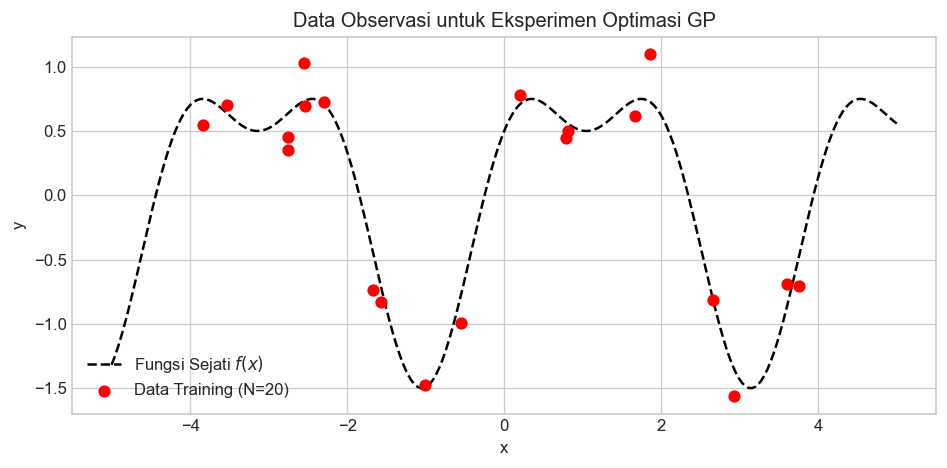

In [2]:
N = 20
X_train = np.sort(np.random.uniform(-4, 4, N))[:, None]
true_func = lambda x: np.sin(1.5 * x) + 0.5 * np.cos(3.0 * x)
sigma_n_true = 0.2
y_train = true_func(X_train).ravel() + np.random.normal(0, sigma_n_true, N)

X_test = np.linspace(-5, 5, 250)[:, None]
y_true_test = true_func(X_test).ravel()

plt.figure(figsize=(8, 4))
plt.plot(X_test, y_true_test, 'k--', label='Fungsi Sejati $f(x)$')
plt.scatter(X_train, y_train, c='red', s=40, zorder=5, label=f'Data Training (N={N})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Observasi untuk Eksperimen Optimasi GP')
plt.legend()
plt.tight_layout()
plt.show()


## 2. Implementasi Algoritma 5.1 Rasmussen & Williams
Fungsi kernel *Squared Exponential*, evaluasi LML, serta gradien analitik menggunakan dekomposisi Cholesky $K_y = L L^T$.


In [3]:
def se_kernel(X1, X2, l, sigma_f):
    r2 = np.sum((X1[:, None, :] - X2[None, :, :])**2, axis=-1)
    return (sigma_f**2) * np.exp(-0.5 * r2 / (l**2))

def compute_lml_components(X, y, l, sigma_f, sigma_n):
    N = len(y)
    K = se_kernel(X, X, l, sigma_f)
    Ky = K + (sigma_n**2 + 1e-7) * np.eye(N)
    
    try:
        L = np.linalg.cholesky(Ky)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        data_fit = -0.5 * np.dot(y, alpha)
        complexity = -np.sum(np.log(np.diag(L)))
        norm_const = -0.5 * N * np.log(2 * np.pi)
        lml = data_fit + complexity + norm_const
        return lml, data_fit, complexity, norm_const
    except np.linalg.LinAlgError:
        return -np.inf, -np.inf, -np.inf, -np.inf

def nlml_and_grad(log_theta, X, y):
    l = np.exp(log_theta[0])
    sigma_f = np.exp(log_theta[1])
    sigma_n = np.exp(log_theta[2])
    N = len(y)
    
    K = se_kernel(X, X, l, sigma_f)
    Ky = K + (sigma_n**2 + 1e-7) * np.eye(N)
    
    L = np.linalg.cholesky(Ky)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    
    # Negative Log Marginal Likelihood (NLML)
    data_fit = -0.5 * np.dot(y, alpha)
    complexity = -np.sum(np.log(np.diag(L)))
    norm_const = -0.5 * N * np.log(2 * np.pi)
    nlml = -(data_fit + complexity + norm_const)
    
    # Matriks bobot gradien W = alpha*alpha^T - Ky^{-1}
    Ky_inv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(N)))
    W = np.outer(alpha, alpha) - Ky_inv
    
    # Turunan parsial matriks kovariansi
    r2 = np.sum((X[:, None, :] - X[None, :, :])**2, axis=-1)
    dK_l = K * (r2 / (l**3))
    dK_sf = 2.0 * sigma_f * np.exp(-0.5 * r2 / (l**2))
    dKy_sn = 2.0 * sigma_n * np.eye(N)
    
    # Gradien dengan aturan rantai log-transform
    grad_l = -0.5 * np.sum(W * dK_l) * l
    grad_sf = -0.5 * np.sum(W * dK_sf) * sigma_f
    grad_sn = -0.5 * np.sum(W * dKy_sn) * sigma_n
    
    return nlml, np.array([grad_l, grad_sf, grad_sn])


## 3. Eksperimen 1: Occam's Razor Trade-off
Melihat bagaimana suku data-fit dan penalti kompleksitas berinteraksi membentuk kurva LML terhadap variasi lengthscale $l$.


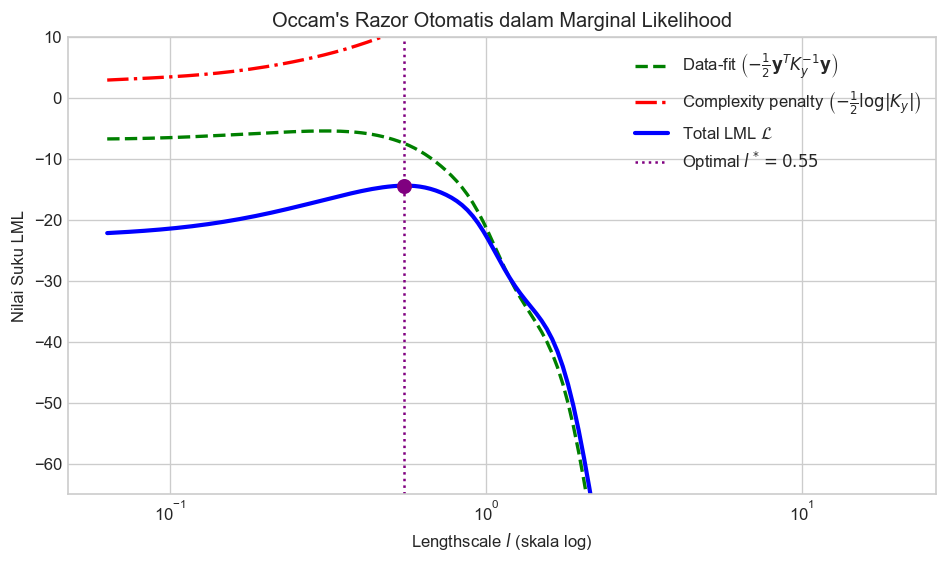

In [4]:
l_values = np.logspace(-1.2, 1.3, 150)
fixed_sigma_f = 1.0
fixed_sigma_n = 0.2

lmls, data_fits, complexities = [], [], []
for l in l_values:
    lml, df, comp, _ = compute_lml_components(X_train, y_train, l, fixed_sigma_f, fixed_sigma_n)
    lmls.append(lml)
    data_fits.append(df)
    complexities.append(comp)

best_idx = np.argmax(lmls)
best_l = l_values[best_idx]

plt.figure(figsize=(8, 4.8))
plt.plot(l_values, data_fits, '--', color='green', lw=2, label=r'Data-fit $\left(-\frac{1}{2}\mathbf{y}^T K_y^{-1}\mathbf{y}\right)$')
plt.plot(l_values, complexities, '-.', color='red', lw=2, label=r'Complexity penalty $\left(-\frac{1}{2}\log|K_y|\right)$')
plt.plot(l_values, lmls, color='blue', lw=2.5, label=r'Total LML $\mathcal{L}$')
plt.axvline(best_l, color='purple', linestyle=':', label=f'Optimal $l^* = {best_l:.2f}$')
plt.plot(best_l, lmls[best_idx], 'o', color='purple', markersize=8)

plt.xscale('log')
plt.xlabel('Lengthscale $l$ (skala log)')
plt.ylabel('Nilai Suku LML')
plt.title("Occam's Razor Otomatis dalam Marginal Likelihood")
plt.ylim(-65, 10)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Eksperimen 2: Menjalankan Optimizer L-BFGS-B
Menemukan parameter optimal secara otomatis menggunakan turunan analitik.


In [5]:
init_theta = np.array([1.0, 1.0, 0.5])
res = minimize(nlml_and_grad, np.log(init_theta), args=(X_train, y_train), jac=True, method='L-BFGS-B')

opt_l, opt_sf, opt_sn = np.exp(res.x)
print("=== HASIL OPTIMASI PARAMETER ===")
print(f"Lengthscale (l)        : {opt_l:.4f}")
print(f"Signal Variance (sf^2) : {opt_sf**2:.4f} (sf = {opt_sf:.4f})")
print(f"Noise Std Dev (sn)     : {opt_sn:.4f} (sn^2 = {opt_sn**2:.4f})")
print(f"Log Marginal Likelihood: {-res.fun:.4f}")


=== HASIL OPTIMASI PARAMETER ===
Lengthscale (l)        : 0.4614
Signal Variance (sf^2) : 0.6813 (sf = 0.8254)
Noise Std Dev (sn)     : 0.1409 (sn^2 = 0.0198)
Log Marginal Likelihood: -13.6742


## 5. Eksperimen 3: Komparasi Fit Model (Underfitting vs Optimal vs Overfitting)


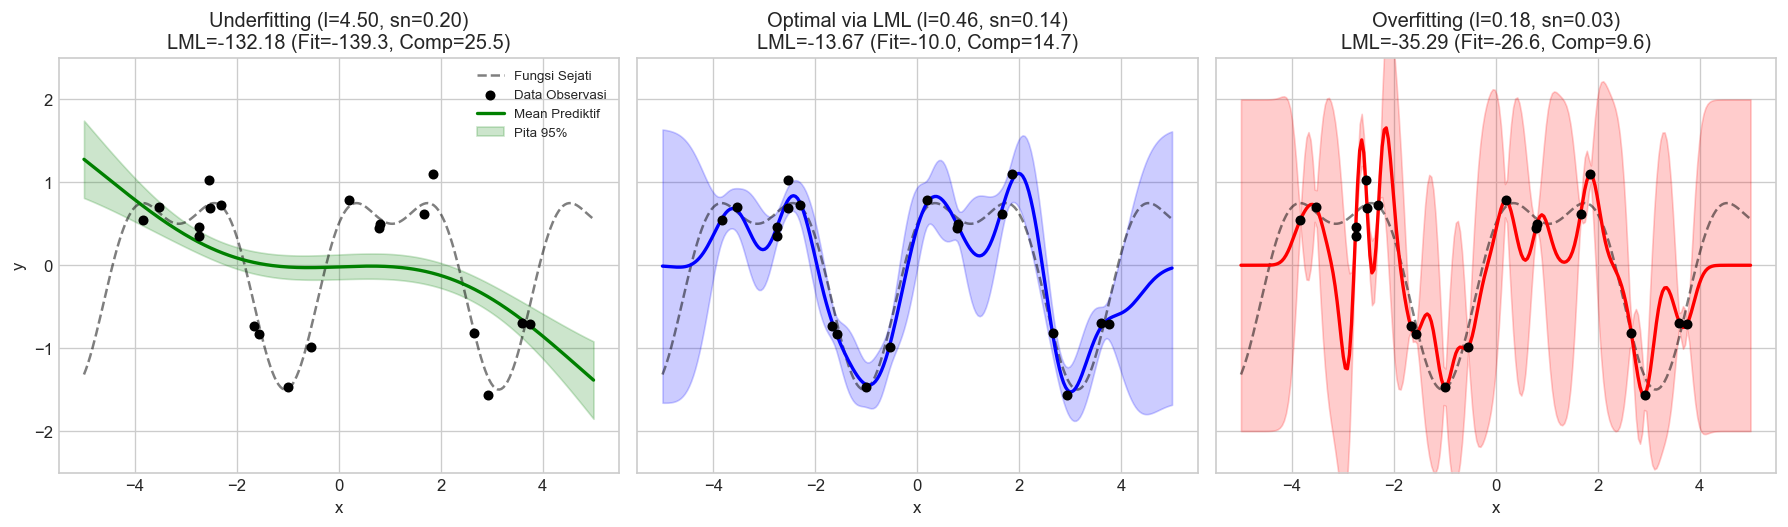

In [6]:
def gp_posterior(X_train, y_train, X_test, l, sigma_f, sigma_n):
    N = len(y_train)
    K_train = se_kernel(X_train, X_train, l, sigma_f) + (sigma_n**2 + 1e-7) * np.eye(N)
    K_s = se_kernel(X_train, X_test, l, sigma_f)
    K_ss = se_kernel(X_test, X_test, l, sigma_f) + 1e-7 * np.eye(len(X_test))
    
    L = np.linalg.cholesky(K_train)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    mu = np.dot(K_s.T, alpha)
    
    v = np.linalg.solve(L, K_s)
    cov = K_ss - np.dot(v.T, v)
    std = np.sqrt(np.maximum(np.diag(cov), 1e-8))
    return mu, std

cases = [
    {'name': 'Underfitting (l=4.50, sn=0.20)', 'l': 4.5, 'sf': 1.0, 'sn': 0.20, 'c': 'green'},
    {'name': f'Optimal via LML (l={opt_l:.2f}, sn={opt_sn:.2f})', 'l': opt_l, 'sf': opt_sf, 'sn': opt_sn, 'c': 'blue'},
    {'name': 'Overfitting (l=0.18, sn=0.03)', 'l': 0.18, 'sf': 1.0, 'sn': 0.03, 'c': 'red'}
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, c in zip(axes, cases):
    mu, std = gp_posterior(X_train, y_train, X_test, c['l'], c['sf'], c['sn'])
    lml, df, comp, _ = compute_lml_components(X_train, y_train, c['l'], c['sf'], c['sn'])
    
    ax.plot(X_test, y_true_test, 'k--', alpha=0.5, label='Fungsi Sejati')
    ax.scatter(X_train, y_train, c='black', s=25, zorder=5, label='Data Observasi')
    ax.plot(X_test, mu, color=c['c'], lw=2, label='Mean Prediktif')
    ax.fill_between(X_test.ravel(), mu - 2*std, mu + 2*std, color=c['c'], alpha=0.2, label='Pita 95%')
    
    ax.set_title(f"{c['name']}\nLML={lml:.2f} (Fit={df:.1f}, Comp={comp:.1f})")
    ax.set_xlabel('x')
    if ax == axes[0]:
        ax.set_ylabel('y')
        ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.show()


## 6. Eksperimen 4: Evaluasi Leave-One-Out Cross-Validation (LOO-CV) Analitik


Log Pseudo-Likelihood (LOO-CV) pada parameter optimal: -3.2214


<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
C:\Users\MyBook Z Series\AppData\Local\Temp\ipykernel_21816\1611959943.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.errorbar(y_train, mu_loo, yerr=2*np.sqrt(sigma2_loo), fmt='o', color='purple', ecolor='gray', elinewidth=1.5, capsize=3, label='Prediksi LOO $\mu_{-i} \pm 2\sigma_{-i}$')
C:\Users\MyBook Z Series\AppData\Local\Temp\ipykernel_21816\1611959943.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.plot([-2, 2], [-2, 2], 'k--', label='Ideal $y_i = \mu_{-i}$')
C:\Users\MyBook Z Series\AppData\Local\Temp\ipykernel_21816\1611959943.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Prediksi LOO $\mu_{-i}$')


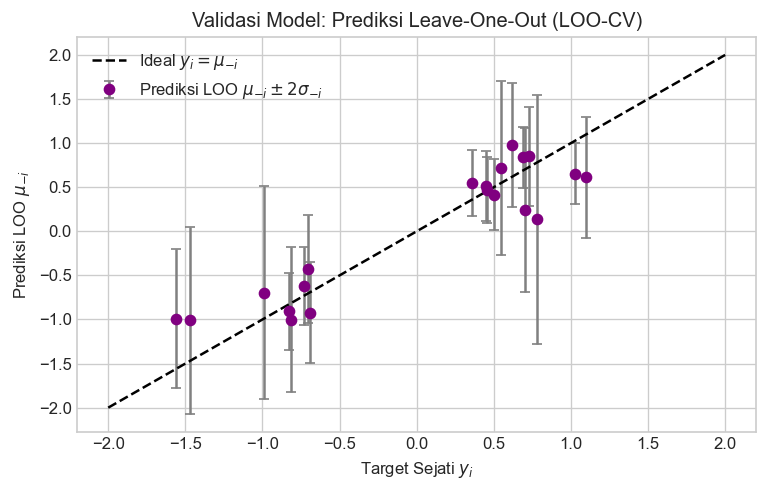

In [7]:
K_opt = se_kernel(X_train, X_train, opt_l, opt_sf) + (opt_sn**2 + 1e-7) * np.eye(N)
L_opt = np.linalg.cholesky(K_opt)
Ky_inv_opt = np.linalg.solve(L_opt.T, np.linalg.solve(L_opt, np.eye(N)))
alpha_opt = np.linalg.solve(L_opt.T, np.linalg.solve(L_opt, y_train))

# LOO-CV Analitik:
mu_loo = y_train - (alpha_opt / np.diag(Ky_inv_opt))
sigma2_loo = 1.0 / np.diag(Ky_inv_opt)

lpl = -0.5 * np.sum(np.log(2 * np.pi * sigma2_loo) + ((y_train - mu_loo)**2 / sigma2_loo))
print(f"Log Pseudo-Likelihood (LOO-CV) pada parameter optimal: {lpl:.4f}")

plt.figure(figsize=(6.5, 4.2))
plt.errorbar(y_train, mu_loo, yerr=2*np.sqrt(sigma2_loo), fmt='o', color='purple', ecolor='gray', elinewidth=1.5, capsize=3, label='Prediksi LOO $\mu_{-i} \pm 2\sigma_{-i}$')
plt.plot([-2, 2], [-2, 2], 'k--', label='Ideal $y_i = \mu_{-i}$')
plt.xlabel('Target Sejati $y_i$')
plt.ylabel('Prediksi LOO $\mu_{-i}$')
plt.title('Validasi Model: Prediksi Leave-One-Out (LOO-CV)')
plt.legend()
plt.tight_layout()
plt.show()
